In [1]:
# ===============================================
# Code Block 1 — Imports, Paths, and Safe File Checks
# ===============================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import shorten

# Configure display (optional)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 200)

# Paths - adjust if your processed folder differs
IN_DIR = "../data/processed"
OUT_DIR = "../data/final"
os.makedirs(OUT_DIR, exist_ok=True)

# Expected input filenames (produced by earlier notebooks)
CASE_HYBRID_FILE     = os.path.join(IN_DIR, "case_hybrid_scores.csv")
RES_HYBRID_FILE      = os.path.join(IN_DIR, "resource_hybrid_scores.csv")
MUNI_HYBRID_FILE     = os.path.join(IN_DIR, "hybrid_performance_model.csv")
EVENT_SCORES_FILE    = os.path.join(IN_DIR, "event_scores.csv")

# Output filenames
FULL_REPORT_CSV = os.path.join(OUT_DIR, "full_performance_report.csv")
DASHBOARD_JSON  = os.path.join(OUT_DIR, "dashboard_ready.json")
EXEC_SUMMARY    = os.path.join(OUT_DIR, "executive_summary.txt")

# Verify files exist (fail early with clear message)
missing_inputs = [f for f in [CASE_HYBRID_FILE, RES_HYBRID_FILE, MUNI_HYBRID_FILE, EVENT_SCORES_FILE] if not os.path.exists(f)]
if missing_inputs:
    raise FileNotFoundError(f"Missing required input files: {missing_inputs}")

print("All input files found. Proceeding...")


All input files found. Proceeding...


In [5]:
# ===============================================
# Code Block 2 — Load CSVs into DataFrames (safe parsing)
# ===============================================

# Use low_memory=False to avoid dtype mixed-type warnings
case_hybrid  = pd.read_csv(CASE_HYBRID_FILE, low_memory=False)
res_hybrid   = pd.read_csv(RES_HYBRID_FILE, low_memory=False)
muni_hybrid  = pd.read_csv(MUNI_HYBRID_FILE, low_memory=False)
event_scores = pd.read_csv(EVENT_SCORES_FILE, low_memory=False)

# Normalize column names to be safe
def normalize_cols(df):
    df.columns = [c.strip() for c in df.columns]
    return df

case_hybrid  = normalize_cols(case_hybrid)
res_hybrid   = normalize_cols(res_hybrid)
muni_hybrid  = normalize_cols(muni_hybrid)
event_scores = normalize_cols(event_scores)

# Quick shapes
print("Loaded shapes:")
print(" case_hybrid:", case_hybrid.shape)
print(" res_hybrid :", res_hybrid.shape)
print(" muni_hybrid:", muni_hybrid.shape)
print(" event_scores:", event_scores.shape)

# Make sure primary keys exist
for df, key, fname in [
    (case_hybrid, "case_id", CASE_HYBRID_FILE),
    (res_hybrid, "resource", RES_HYBRID_FILE),
    (muni_hybrid, "municipality", MUNI_HYBRID_FILE),
    (event_scores, "event_id", EVENT_SCORES_FILE),
]:
    if key not in df.columns:
        raise KeyError(f"Required column '{key}' missing from {fname}")


Loaded shapes:
 case_hybrid: (3183, 4)
 res_hybrid : (64, 4)
 muni_hybrid: (5, 34)
 event_scores: (262628, 13)


In [6]:
# ===============================================
# Code Block 3 — Basic Normalization and Indexing
# ===============================================

# Ensure consistent dtypes for join keys
case_hybrid["case_id"] = case_hybrid["case_id"].astype(str)
event_scores["case_id"] = event_scores["case_id"].astype(str)
# event_id may be numeric or string — normalize to str for stable lookups
event_scores["event_id"] = event_scores["event_id"].astype(str)
if "event_id" in case_hybrid.columns:
    case_hybrid["event_id"] = case_hybrid["event_id"].astype(str)

# Resources and municipalities
res_hybrid["resource"] = res_hybrid["resource"].astype(str)
if "municipality" in case_hybrid.columns:
    case_hybrid["municipality"] = case_hybrid["municipality"].astype(str)
if "municipality" in event_scores.columns:
    event_scores["municipality"] = event_scores["municipality"].astype(str)
if "municipality" in res_hybrid.columns:
    res_hybrid["municipality"] = res_hybrid["municipality"].astype(str)
muni_hybrid["municipality"] = muni_hybrid["municipality"].astype(str)

# Set indexes for fast lookups
case_idx = case_hybrid.set_index("case_id", drop=False)
res_idx  = res_hybrid.set_index("resource", drop=False)
muni_idx = muni_hybrid.set_index("municipality", drop=False)
event_idx = event_scores.set_index("event_id", drop=False)

print("Indexes prepared.")


Indexes prepared.


In [7]:
# ===============================================
# Code Block 4 — Build Full Merged Report (per-event, with associated case/resource/muni scores)
# ===============================================

# Start from events (one row per event); merge case/resource/municipality scores for context.
events_full = event_scores.copy()

# Merge case hybrid info (case_id key)
events_full["case_id"] = events_full["case_id"].astype(str)
events_full = events_full.merge(
    case_hybrid[["case_id", "case_hybrid_score", "case_hybrid_raw", "municipality"]],
    on="case_id",
    how="left",
    suffixes=("", "_case")
)

# Merge resource hybrid info (resource key)
if "resource" in events_full.columns:
    events_full["resource"] = events_full["resource"].astype(str)
    events_full = events_full.merge(
        res_hybrid[["resource", "resource_hybrid_score", "resource_hybrid_raw"]],
        on="resource",
        how="left"
    )

# Merge municipality hybrid (if not present already)
events_full = events_full.merge(
    muni_hybrid[["municipality", "hybrid_score", "performance_index"]],
    on="municipality",
    how="left",
    suffixes=("", "_muni")
)

# Round numeric score fields to 3 decimal places (as requested)
round_cols = [c for c in events_full.columns if "score" in c or "raw" in c or "performance_index" in c]
for c in round_cols:
    try:
        events_full[c] = pd.to_numeric(events_full[c], errors="coerce").round(3)
    except Exception:
        pass

# Save a compressed view for debugging if needed
events_full_sample = events_full.head(10)
print("Built events_full with shape:", events_full.shape)
display(events_full_sample)


Built events_full with shape: (262628, 20)


,event_id,case_id,resource,event_score,ev_prev_gap,ev_next_gap,ev_gap_ratio_prev,ev_rework_prior,ev_event_pos,ev_activity_freq,ev_resource_freq,ev_case_score,ev_resource_score,case_hybrid_score,case_hybrid_raw,municipality,resource_hybrid_score,resource_hybrid_raw,hybrid_score,performance_index
0,nan,10002463,1550894,0.792,0.722,0.057,0.722,0.738,0.994,0.861,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
1,nan,10002463,1550894,0.672,0.057,0.722,0.054,0.738,0.982,0.808,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
2,nan,10002463,1550894,0.819,0.722,0.722,0.722,0.738,0.970,0.384,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
3,nan,10002463,1550894,0.798,0.722,0.722,0.722,0.738,0.958,0.169,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
4,nan,10002463,1550894,0.811,0.722,0.722,0.722,0.738,0.946,0.355,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
5,nan,10002463,1550894,0.857,0.722,0.722,0.722,0.738,0.934,0.949,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
6,nan,10002463,1550894,0.817,0.722,0.722,0.722,0.738,0.922,0.492,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
7,nan,10002463,1550894,0.854,0.722,0.722,0.722,0.738,0.910,0.983,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
8,nan,10002463,1550894,0.839,0.722,0.722,0.722,0.738,0.898,0.829,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358
9,nan,10002463,1550894,0.805,0.722,0.722,0.722,0.738,0.886,0.450,0.369,0.723,0.469,0.834,0.828,BPIC15_4,0.582,0.458,0.0,0.358


In [8]:
# ===============================================
# Code Block 5 — Build Per-Case Final Table (merge event- and resource-level info)
# ===============================================

# Compose case-level final table using case_hybrid and aggregated event metrics (if available)
case_final = case_hybrid.copy()

# Attach aggregated event metrics per case if present in events_full:
# - mean event_score, median event_score, count of events
ev_agg = events_full.groupby("case_id").agg(
    n_events_case = ("event_id", "count"),
    event_score_mean = ("event_score", lambda s: pd.to_numeric(s, errors="coerce").mean()),
    event_score_median = ("event_score", lambda s: pd.to_numeric(s, errors="coerce").median())
).reset_index()

case_final = case_final.merge(ev_agg, on="case_id", how="left")

# Attach avg resource score inside each case (if present)
if "ev_resource_score" in events_full.columns:
    ragg = events_full.groupby("case_id")["ev_resource_score"].mean().reset_index(name="avg_resource_score_in_case")
    case_final = case_final.merge(ragg, on="case_id", how="left")

# Round scores to 3 decimals and fill missing sensibly
for c in ["case_hybrid_score", "event_score_mean", "event_score_median", "avg_resource_score_in_case"]:
    if c in case_final.columns:
        case_final[c] = pd.to_numeric(case_final[c], errors="coerce").round(3)

print("case_final shape:", case_final.shape)
display(case_final.head())


case_final shape: (3183, 8)


,case_id,municipality,case_hybrid_score,case_hybrid_raw,n_events_case,event_score_mean,event_score_median,avg_resource_score_in_case
0,10002463,BPIC15_4,0.834,0.827516,46,0.737,0.760,0.469
1,10003257,BPIC15_4,0.914,0.903030,13,0.907,0.924,0.939
2,10009280,BPIC15_1,0.856,0.847945,45,0.822,0.840,0.649
3,10044881,BPIC15_4,0.918,0.907222,13,0.926,0.952,0.939
4,10051546,BPIC15_1,0.445,0.458088,57,0.717,0.727,0.649


In [9]:
# ===============================================
# Code Block 6 — Build Per-Resource Final Table (aggregate case/event context)
# ===============================================

res_final = res_hybrid.copy()

# attach event-level aggregates per resource
ev_res_agg = events_full.groupby("resource").agg(
    n_events_handled = ("event_id", "count"),
    event_score_mean_resource = ("event_score", lambda s: pd.to_numeric(s, errors="coerce").mean())
).reset_index()

res_final = res_final.merge(ev_res_agg, on="resource", how="left")

# attach average case hybrid score for cases the resource participated in
if "case_id" in events_full.columns:
    avg_case_by_res = (
        events_full[["resource","case_id"]]
        .drop_duplicates()
        .merge(case_hybrid[["case_id","case_hybrid_score"]], on="case_id", how="left")
        .groupby("resource")["case_hybrid_score"]
        .mean()
        .reset_index(name="avg_case_hybrid_score")
    )
    res_final = res_final.merge(avg_case_by_res, on="resource", how="left")

# Round numeric values
for c in ["resource_hybrid_score", "event_score_mean_resource", "avg_case_hybrid_score"]:
    if c in res_final.columns:
        res_final[c] = pd.to_numeric(res_final[c], errors="coerce").round(3)

print("res_final shape:", res_final.shape)
display(res_final.head())


res_final shape: (64, 7)


,resource,municipality,resource_hybrid_score,resource_hybrid_raw,n_events_handled,event_score_mean_resource,avg_case_hybrid_score
0,10716070,BPIC15_1,0.083,0.175869,96,0.478,0.240
1,1550894,BPIC15_4,0.582,0.458375,12875,0.513,0.642
2,1946514,BPIC15_3,0.452,0.384731,180,0.660,0.725
3,2013365,BPIC15_3,0.616,0.477811,12905,0.523,0.647
4,2670601,BPIC15_1,0.584,0.459779,1363,0.681,0.796


In [10]:
# ===============================================
# Code Block 7 — Municipality Final Table (SAFE merge + diagnostics)
# ===============================================

muni_final = muni_hybrid.copy()

print("\n[Diagnostics] Checking municipality column presence:")
print(" case_final has municipality:", "municipality" in case_final.columns)
print(" res_final has municipality:", "municipality" in res_final.columns)
print(" events_full has municipality:", "municipality" in events_full.columns)

# ----------------------------
# 1. Build COUNT tables safely
# ----------------------------

# CASE counts
if "municipality" in case_final.columns:
    case_counts = (
        case_final.groupby("municipality")["case_id"]
        .nunique()
        .reset_index(name="n_cases")
    )
else:
    case_counts = pd.DataFrame(columns=["municipality", "n_cases"])

# RESOURCE counts
if "municipality" in res_final.columns:
    res_counts = (
        res_final.groupby("municipality")["resource"]
        .nunique()
        .reset_index(name="n_resources")
    )
else:
    res_counts = pd.DataFrame(columns=["municipality", "n_resources"])

# EVENT counts
if "municipality" in events_full.columns:
    event_counts = (
        events_full.groupby("municipality")["event_id"]
        .count()
        .reset_index(name="n_events")
    )
else:
    event_counts = pd.DataFrame(columns=["municipality", "n_events"])

# ----------------------------
# 2. MERGE all counts safely
# ----------------------------
for df_cnt in [case_counts, res_counts, event_counts]:
    muni_final = muni_final.merge(df_cnt, on="municipality", how="left")

# ----------------------------
# 3. Fill missing with zeros
# ----------------------------
for col in ["n_cases", "n_resources", "n_events"]:
    if col not in muni_final.columns:
        muni_final[col] = 0
    muni_final[col] = muni_final[col].fillna(0).astype(int)

# ----------------------------
# 4. Round municipality hybrid metrics
# ----------------------------
for c in ["hybrid_score", "performance_index"]:
    if c in muni_final.columns:
        muni_final[c] = pd.to_numeric(muni_final[c], errors="coerce").round(3)

print("\nmuni_final shape:", muni_final.shape)
display(muni_final.head())



[Diagnostics] Checking municipality column presence:
 case_final has municipality: True
 res_final has municipality: True
 events_full has municipality: True

muni_final shape: (5, 39)


,municipality,n_cases_x,avg_cycle_hours,avg_wait_hours,avg_processing_hours,avg_rework,avg_cost,std_cycle_hours,variant_complexity,n_unique_variants,overdue_rate,n_resources_x,avg_handover_in,avg_handover_out,avg_processing_hours_res,avg_wait_hours_res,handovers_per_case,avg_cycle_hours_norm,avg_wait_hours_norm,avg_cost_norm,avg_rework_norm,overdue_rate_norm,avg_handover_out_norm,handovers_per_case_norm,performance_index_raw,performance_index,rank,muni_outlier,avg_case_hybrid_score,avg_resource_hybrid_score,avg_event_score,outlier_penalty_muni,hybrid_score_raw,hybrid_score,n_cases_y,n_resources_y,n_events,n_cases,n_resources
0,BPIC15_1,810,2346.385508,2346.385508,0.0,3.541975,104027.618765,2863.190953,44.241975,796,0.0,21,120.333333,120.285714,106.129609,45.338299,2527.0,0.304077,0.304077,0.030562,0.000000,0.0,0.000000,0.405175,0.192085,0.808,2,False,0.695023,0.403762,0.707886,0.0,0.770805,0.816,810,21,35836,0,0
1,BPIC15_2,310,3770.189789,3770.189789,0.0,4.164516,97524.171404,3248.651639,55.122581,309,0.0,6,496.333333,496.333333,65.873137,19.182486,2978.0,1.000000,1.000000,0.000000,0.003425,0.0,1.000000,0.679756,0.634330,0.366,4,False,0.633748,0.371000,0.715545,0.0,0.268881,0.020,310,6,17088,0,0
2,BPIC15_3,804,1724.267544,1724.267544,0.0,3.767413,151821.381975,2524.220728,43.584577,769,0.0,20,186.150000,186.150000,64.611105,33.944504,1861.5,0.000000,0.000000,0.255162,0.001240,0.0,0.175149,0.000000,0.047156,0.953,1,False,0.687735,0.398300,0.716560,0.0,0.886862,1.000,804,20,35042,0,0
3,BPIC15_4,622,2932.718776,2932.718776,0.0,185.311897,310319.419781,3373.633607,228.004823,618,0.0,9,342.666667,342.777778,81.202519,31.182385,3084.0,0.590663,0.590663,1.000000,1.000000,0.0,0.591659,0.744292,0.641662,0.358,5,True,0.683254,0.473111,0.703309,1.0,0.256136,0.000,622,9,141819,0,0
4,BPIC15_5,637,2552.882832,2552.882832,0.0,4.029827,144841.536092,2853.616028,51.558870,635,0.0,8,438.000000,438.000000,54.468851,35.875489,3504.0,0.405008,0.405008,0.222361,0.002684,0.0,0.844878,1.000000,0.348621,0.651,3,False,0.692427,0.550000,0.709184,0.0,0.529802,0.434,637,8,32843,0,0


In [11]:
# ===============================================
# Code Block 8 — Save full_performance_report.csv and smaller slices
# ===============================================

# Compose a full report join (event-level rows already have everything)
# also create compact slices for dashboard use
events_full.to_csv(FULL_REPORT_CSV, index=False)
case_final.to_csv(os.path.join(OUT_DIR, "cases_final.csv"), index=False)
res_final.to_csv(os.path.join(OUT_DIR, "resources_final.csv"), index=False)
muni_final.to_csv(os.path.join(OUT_DIR, "municipalities_final.csv"), index=False)

print("Saved full and slice outputs to:", OUT_DIR)
print("Files created:")
print(" -", FULL_REPORT_CSV)
print(" -", os.path.join(OUT_DIR, "cases_final.csv"))
print(" -", os.path.join(OUT_DIR, "resources_final.csv"))
print(" -", os.path.join(OUT_DIR, "municipalities_final.csv"))


Saved full and slice outputs to: ../data/final
Files created:
 - ../data/final\full_performance_report.csv
 - ../data/final\cases_final.csv
 - ../data/final\resources_final.csv
 - ../data/final\municipalities_final.csv


In [12]:
# ===============================================
# Code Block 9 — Executive Summary Generation (simple template)
# ===============================================

def build_executive_summary(muni_df, case_df, res_df, events_df, top_n=5):
    lines = []
    lines.append("Hybrid Performance Model — Executive Summary")
    lines.append("-------------------------------------------")
    # best / worst municipalities
    if "hybrid_score" in muni_df.columns:
        best_m = muni_df.sort_values("hybrid_score", ascending=False).head(1).iloc[0]
        worst_m = muni_df.sort_values("hybrid_score", ascending=True).head(1).iloc[0]
        lines.append(f"Top municipality: {best_m['municipality']} (score={best_m.get('hybrid_score')})")
        lines.append(f"Worst municipality: {worst_m['municipality']} (score={worst_m.get('hybrid_score')})")
    # top cases
    if "case_hybrid_score" in case_df.columns:
        top_cases = case_df.sort_values("case_hybrid_score", ascending=False).head(top_n)[["case_id","municipality","case_hybrid_score"]]
        lines.append("\nTop case examples:")
        for _, r in top_cases.iterrows():
            lines.append(f" - case {r['case_id']} (muni={r['municipality']}) score={r['case_hybrid_score']}")
    # top resources
    if "resource_hybrid_score" in res_df.columns:
        top_res = res_df.sort_values("resource_hybrid_score", ascending=False).head(top_n)[["resource","resource_hybrid_score"]]
        lines.append("\nTop resources:")
        for _, r in top_res.iterrows():
            lines.append(f" - resource {r['resource']} score={r['resource_hybrid_score']}")
    # brief event stats
    lines.append("\nEvent statistics:")
    lines.append(f" - total events: {len(events_df)}")
    lines.append(f" - total cases: {case_df['case_id'].nunique()}")
    lines.append(f" - total resources: {res_df['resource'].nunique()}")
    return "\n".join(lines)

exec_summary_text = build_executive_summary(muni_final, case_final, res_final, events_full, top_n=5)

# Save to file
with open(EXEC_SUMMARY, "w", encoding="utf-8") as f:
    f.write(exec_summary_text)

print("Executive summary saved to:", EXEC_SUMMARY)
print("\n--- Executive summary preview ---")
print(exec_summary_text)


Executive summary saved to: ../data/final\executive_summary.txt

--- Executive summary preview ---
Hybrid Performance Model — Executive Summary
-------------------------------------------
Top municipality: BPIC15_3 (score=1.0)
Worst municipality: BPIC15_4 (score=0.0)

Top case examples:
 - case 5565409 (muni=BPIC15_4) score=1.0
 - case 4568005 (muni=BPIC15_1) score=0.971
 - case 11070999 (muni=BPIC15_5) score=0.963
 - case 5597050 (muni=BPIC15_4) score=0.962
 - case 7762378 (muni=BPIC15_3) score=0.959

Top resources:
 - resource 4901428 score=1.0
 - resource 560852 score=0.908
 - resource 560604 score=0.817
 - resource 560454 score=0.803
 - resource 560464 score=0.751

Event statistics:
 - total events: 262628
 - total cases: 3183
 - total resources: 64


In [13]:
# ===============================================
# Code Block 10 — Dashboard JSON export (dashboard_ready.json)
# ===============================================

# Prepare a compact JSON payload with top lists and distributions
dashboard_payload = {
    "top_municipalities": muni_final.sort_values("hybrid_score", ascending=False).head(10)[["municipality","hybrid_score"]].to_dict(orient="records"),
    "top_cases": case_final.sort_values("case_hybrid_score", ascending=False).head(10)[["case_id","case_hybrid_score","municipality"]].to_dict(orient="records"),
    "top_resources": res_final.sort_values("resource_hybrid_score", ascending=False).head(10)[["resource","resource_hybrid_score"]].to_dict(orient="records"),
    "counts": {
        "n_cases": int(case_final["case_id"].nunique()),
        "n_resources": int(res_final["resource"].nunique()),
        "n_municipalities": int(muni_final["municipality"].nunique()),
        "n_events": int(events_full.shape[0])
    }
}

with open(DASHBOARD_JSON, "w", encoding="utf-8") as f:
    json.dump(dashboard_payload, f, indent=2)

print("Saved dashboard JSON to:", DASHBOARD_JSON)


Saved dashboard JSON to: ../data/final\dashboard_ready.json


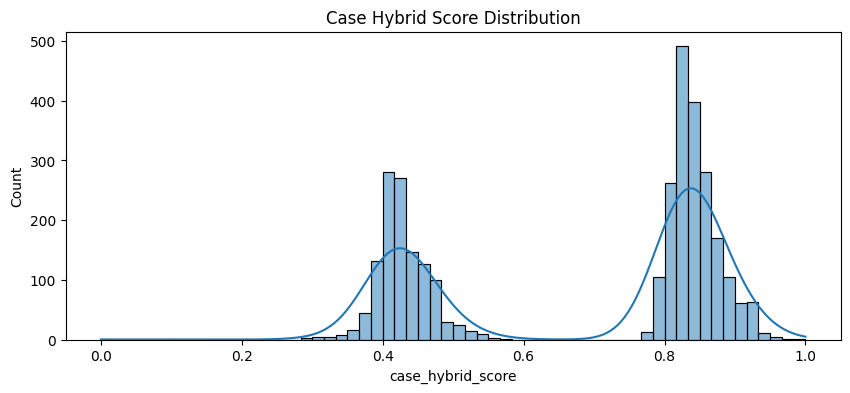

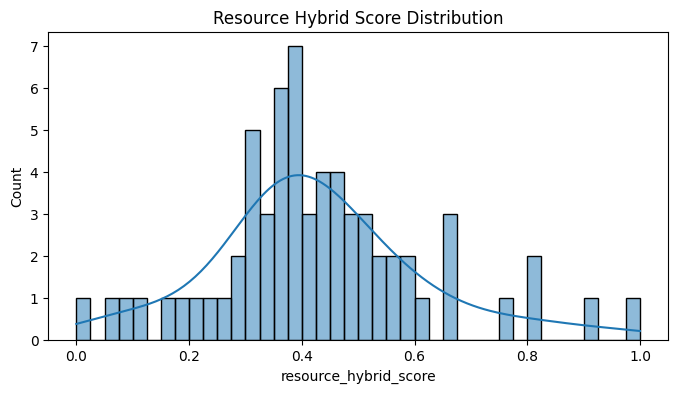

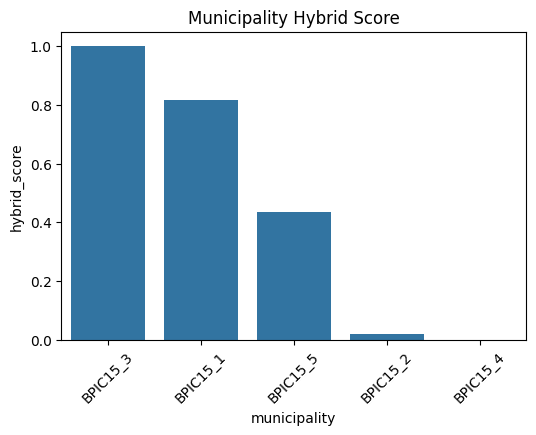

In [14]:
# ===============================================
# Code Block 11 — Diagnostic Plots (optional visuals)
# ===============================================

# Distribution of hybrid scores
plt.figure(figsize=(10,4))
sns.histplot(case_final["case_hybrid_score"].dropna(), kde=True, bins=60)
plt.title("Case Hybrid Score Distribution")
plt.xlabel("case_hybrid_score")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(res_final["resource_hybrid_score"].dropna(), kde=True, bins=40)
plt.title("Resource Hybrid Score Distribution")
plt.xlabel("resource_hybrid_score")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x=muni_final.sort_values("hybrid_score", ascending=False)["municipality"],
            y=muni_final.sort_values("hybrid_score", ascending=False)["hybrid_score"])
plt.title("Municipality Hybrid Score")
plt.xticks(rotation=45)
plt.show()


In [15]:
# ===============================================
# Code Block 12 — Build Search Functions (detailed) - search_case, search_resource, search_municipality, search_event
# ===============================================

# Helper: safe retrieval utilities
def safe_get(df_idx, key, default=None):
    try:
        return df_idx.loc[str(key)]
    except Exception:
        return default

# Search case: returns dict and prints readable report
def search_case(case_id, top_k_events=5):
    case_id = str(case_id)
    c = safe_get(case_idx, case_id)
    if c is None:
        print(f"Case '{case_id}' not found.")
        return None

    # build return dict
    out = {
        "case_id": case_id,
        "municipality": c.get("municipality", None),
        "case_hybrid_score": float(np.round(pd.to_numeric(c.get("case_hybrid_score", np.nan), errors="coerce"),3)) if "case_hybrid_score" in c else None,
        "case_hybrid_raw": float(np.round(pd.to_numeric(c.get("case_hybrid_raw", np.nan), errors="coerce"),3)) if "case_hybrid_raw" in c else None
    }

    # event-level details for this case
    evs = events_full[events_full["case_id"] == case_id].copy()
    if not evs.empty:
        # top events by event_score
        evs["event_score"] = pd.to_numeric(evs["event_score"], errors="coerce")
        top_e = evs.sort_values("event_score", ascending=False).head(top_k_events)[["event_id","timestamp","resource","event_score"]].to_dict(orient="records")
        bottom_e = evs.sort_values("event_score", ascending=True).head(top_k_events)[["event_id","timestamp","resource","event_score"]].to_dict(orient="records")
        out["n_events"] = int(evs.shape[0])
        out["event_score_mean"] = float(np.round(evs["event_score"].mean(),3))
        out["top_events"] = top_e
        out["bottom_events"] = bottom_e
    else:
        out["n_events"] = 0
        out["event_score_mean"] = None
        out["top_events"] = []
        out["bottom_events"] = []

    # resource summary for cases that participated
    res_list = evs.groupby("resource")["event_score"].agg(["count","mean"]).reset_index().sort_values("mean", ascending=False)
    out["resources_in_case_count"] = int(res_list.shape[0])
    out["resources_sample"] = res_list.head(5).to_dict(orient="records")

    # outlier flags if available
    if "case_outlier" in case_idx.columns:
        out["case_outlier"] = bool(case_idx.loc[case_id].get("case_outlier", False))

    # Print readable summary
    print(f"CASE REPORT — case_id: {case_id}")
    print(f" municipality: {out['municipality']}")
    print(f" hybrid score: {out['case_hybrid_score']} (raw={out['case_hybrid_raw']})")
    print(f" events: {out['n_events']}, mean event score: {out['event_score_mean']}")
    print(" Top events (sample):")
    for e in out["top_events"]:
        print(f"  - event {e['event_id']}, resource={e['resource']}, score={e['event_score']}")
    return out

# Search resource
def search_resource(resource_name, top_k_cases=5):
    rname = str(resource_name)
    r = safe_get(res_idx, rname)
    if r is None:
        print(f"Resource '{rname}' not found.")
        return None

    out = {
        "resource": rname,
        "resource_hybrid_score": float(np.round(pd.to_numeric(r.get("resource_hybrid_score", np.nan), errors="coerce"),3)) if "resource_hybrid_score" in r else None,
        "workload_n_events": int(r.get("n_events", 0)) if "n_events" in r else None
    }

    evs = events_full[events_full["resource"] == rname].copy()
    if not evs.empty:
        evs["event_score"] = pd.to_numeric(evs["event_score"], errors="coerce")
        out["event_score_mean"] = float(np.round(evs["event_score"].mean(),3))
        # top cases this resource participated in (by average event score)
        top_cases = (evs.groupby("case_id")["event_score"].mean().reset_index().sort_values("event_score", ascending=False).head(top_k_cases))
        out["top_cases_sample"] = top_cases.to_dict(orient="records")
    else:
        out["event_score_mean"] = None
        out["top_cases_sample"] = []

    # print summary
    print(f"RESOURCE REPORT — resource: {rname}")
    print(f" hybrid score: {out['resource_hybrid_score']}, events handled: {out['workload_n_events']}")
    print(f" avg event score handled: {out['event_score_mean']}")
    return out

# Search municipality
def search_municipality(muni_name, top_k=10):
    muni_name = str(muni_name)
    m = safe_get(muni_idx, muni_name)
    if m is None:
        print(f"Municipality '{muni_name}' not found.")
        return None

    out = {
        "municipality": muni_name,
        "municipality_hybrid_score": float(np.round(pd.to_numeric(m.get("hybrid_score", np.nan), errors="coerce"),3)) if "hybrid_score" in m else None,
        "performance_index": float(np.round(pd.to_numeric(m.get("performance_index", np.nan), errors="coerce"),3)) if "performance_index" in m else None
    }

    # basic aggregations
    cases_in_m = case_final[case_final["municipality"] == muni_name]
    resources_in_m = res_final[res_final["municipality"] == muni_name] if "municipality" in res_final.columns else pd.DataFrame()
    events_in_m = events_full[events_full["municipality"] == muni_name]

    out["n_cases"] = int(cases_in_m.shape[0])
    out["n_resources"] = int(resources_in_m.shape[0])
    out["n_events"] = int(events_in_m.shape[0])
    out["case_hybrid_mean"] = float(np.round(cases_in_m["case_hybrid_score"].mean(),3)) if not cases_in_m.empty and "case_hybrid_score" in cases_in_m.columns else None
    out["resource_hybrid_mean"] = float(np.round(resources_in_m["resource_hybrid_score"].mean(),3)) if not resources_in_m.empty and "resource_hybrid_score" in resources_in_m.columns else None
    out["event_score_mean"] = float(np.round(events_in_m["event_score"].mean(),3)) if not events_in_m.empty and "event_score" in events_in_m.columns else None

    # sample top/bottom cases
    out["top_cases"] = cases_in_m.sort_values("case_hybrid_score", ascending=False).head(top_k)[["case_id","case_hybrid_score"]].to_dict(orient="records")
    out["worst_cases"] = cases_in_m.sort_values("case_hybrid_score", ascending=True).head(top_k)[["case_id","case_hybrid_score"]].to_dict(orient="records")

    # print summary
    print(f"MUNICIPALITY REPORT — {muni_name}")
    print(f" hybrid score: {out['municipality_hybrid_score']}, performance_index: {out['performance_index']}")
    print(f" cases: {out['n_cases']}, resources: {out['n_resources']}, events: {out['n_events']}")
    return out

# Search event
def search_event(event_id):
    eid = str(event_id)
    e = safe_get(event_idx, eid)
    if e is None:
        print(f"Event '{eid}' not found.")
        return None

    # event-level info plus linked scores
    out = e.to_dict()
    # enrich with numeric rounding for scores if present
    for k in ["event_score","ev_case_score","ev_resource_score"]:
        if k in out:
            try:
                out[k] = float(np.round(pd.to_numeric(out[k], errors="coerce"),3))
            except Exception:
                pass

    # include linked case/resource hybrid scores
    case_id = str(out.get("case_id")) if out.get("case_id") is not None else None
    if case_id and case_id in case_idx.index:
        out["case_hybrid_score"] = float(np.round(pd.to_numeric(case_idx.loc[case_id].get("case_hybrid_score", np.nan), errors="coerce"),3))
    res = out.get("resource")
    if res and res in res_idx.index:
        out["resource_hybrid_score"] = float(np.round(pd.to_numeric(res_idx.loc[res].get("resource_hybrid_score", np.nan), errors="coerce"),3))

    # print brief summary
    print(f"EVENT REPORT — event_id: {eid}")
    print(f" case: {case_id}, resource: {out.get('resource')}, event_score: {out.get('event_score')}")
    return out


In [16]:
# ===============================================
# Code Block 13 — Unified API wrapper: search_entity (auto-detects type)
# ===============================================

def search_entity(identifier, verbose=True, **kwargs):
    """
    Unified search. Tries to detect whether identifier is:
      - a case_id (present in case_idx)
      - a resource (present in res_idx)
      - a municipality (present in muni_idx)
      - an event_id (present in event_idx)
    Returns (result_dict, entity_type) or (None, None) if not found.
    """
    sid = str(identifier)
    if sid in case_idx.index:
        res = search_case(sid, **kwargs)
        if verbose:
            return res
        return res, "case"
    if sid in res_idx.index:
        res = search_resource(sid, **kwargs)
        if verbose:
            return res
        return res, "resource"
    if sid in muni_idx.index:
        res = search_municipality(sid, **kwargs)
        if verbose:
            return res
        return res, "municipality"
    if sid in event_idx.index:
        res = search_event(sid)
        if verbose:
            return res
        return res, "event"
    # Not found: attempt fuzzy detection by checking case_id as numeric-like
    # Try match as case_id even if types differ
    if sid in case_idx.index:
        return search_case(sid)
    print("Identifier not found in cases, resources, municipalities, or events.")
    return None

# Example usage (uncomment to test)
# search_case("10002463")
# search_resource("1550894")
# search_municipality("BPIC15_4")
# search_event("0")   # or real event id from your event_scores.csv


In [17]:
# ===============================================
# Code Block 14 — Finalization: small QA and message
# ===============================================

print("Notebook 9D completed.")
print("Saved artifacts available in:", OUT_DIR)
print(" - full_performance_report.csv (event-level merged)")
print(" - cases_final.csv, resources_final.csv, municipalities_final.csv")
print(" - dashboard_ready.json")
print(" - executive_summary.txt")
print("\nUse `search_entity(id)` to lookup case/resource/municipality/event quickly.")


Notebook 9D completed.
Saved artifacts available in: ../data/final
 - full_performance_report.csv (event-level merged)
 - cases_final.csv, resources_final.csv, municipalities_final.csv
 - dashboard_ready.json
 - executive_summary.txt

Use `search_entity(id)` to lookup case/resource/municipality/event quickly.
